In [1]:
# Designs a 150 ns NOT gate (pi rotation) that is robust against
# time-dependent detuning and minimizes leakage into the |2> state.
#
# Robustness is achieved by assuming a detuning of the form:
#             delta(t) = A*cos(2*pi*w*t)
# and optimizing the gate over a grid of w in [0, 10 MHz] and
# A in [-5 MHz, 5 MHz] to ensure high fidelity across this range.
#
# The control pulse is decomposed into a Fourier series with n in {1,...,10}.
# The pulse amplitude is constrained such that (Ωx^2+Ωy^2)^(1/2) < 20 MHz.
# Estimated script runtime: ~15 minutes.

# AUTHOR:
#     Leo Van Damme / Technical University of Munich, 2025

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from grape_scq import Transmon, GateTarget, OptimizationProblem, GrapeOptimizer, initial_guess, analysis
from grape_scq.bases import symmetric_fourier_basis, antisymmetric_fourier_basis

In [3]:
# Build the time-dependent detuning ensemble: a grid of (w, A) pairs, each
# giving its own (n_steps,)-shaped detuning trace delta(t) = A*cos(2*pi*w*t)
n_steps = 150
dt = 1e-9
tc = np.arange(n_steps) * dt
Nw, NA = 5, 5
w = np.linspace(0, 10e6, Nw)
A = np.linspace(-5e6, 5e6, NA)
wGrid, AGrid = np.meshgrid(w, A)
detuning = AGrid.ravel()[:, None] * np.cos(2*np.pi*wGrid.ravel()[:, None] * tc[None, :])

system = Transmon(n_levels=3, frequency=5e9 + detuning, carrier_frequency=5e9, anharmonicity=-100e6)
system.grid_shape = wGrid.shape
system.grid_axes = {"w": w, "A": A}

target = GateTarget(matrix=[[0, 1], [1, 0]], subspace=[0, 1])

In [4]:
# Analytic pulse basis (Fourier series)
Ncoeffs = 10
fx = symmetric_fourier_basis(n_steps, Ncoeffs)
fy = antisymmetric_fourier_basis(n_steps, Ncoeffs)
problem = OptimizationProblem(system, target, n_steps=n_steps, dt=dt, ux_basis=fx, uy_basis=fy)

In [5]:
# Initial guess: DRAG-like pulse
pulse0 = initial_guess.cos_drag(problem, theta=np.pi)

In [6]:
# Optimize with an amplitude constraint
optimizer = GrapeOptimizer(max_iter=2000, max_amplitude=20e6)
result = optimizer.optimize(problem, pulse0)

Compiling cost function... Done.
GRAPE optimization result
  cost:      0.292136 -> 0.022906
  fidelity:  0.707864 -> 0.977094
  iterations: 2000
  message:   The maximum number of function evaluations is exceeded.


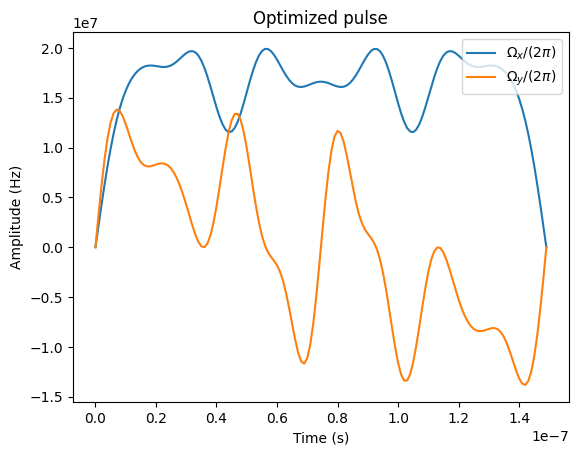

In [7]:
# Display in-phase and quadrature pulse components
result.plot_pulse(compare_to_initial=False)
plt.title("Optimized pulse")
plt.show()

In [8]:
# Extend the grid for a finer fidelity map, and compare against the initial guess
Nw2, NA2 = 25, 25
w2 = np.linspace(0, 12e6, Nw2)
A2 = np.linspace(-7e6, 7e6, NA2)
wGrid2, AGrid2 = np.meshgrid(w2, A2)
detuning2 = AGrid2.ravel()[:, None] * np.cos(2*np.pi*wGrid2.ravel()[:, None] * tc[None, :])

fine_system = Transmon(n_levels=3, frequency=5e9 + detuning2, carrier_frequency=5e9, anharmonicity=-100e6)
fine_system.grid_shape = wGrid2.shape
fine_system.grid_axes = {"w": w2, "A": A2}
fine_problem = problem.with_system(fine_system)

F = analysis.fidelity_map(fine_problem, result.pulse).reshape(fine_system.grid_shape)
F0 = analysis.fidelity_map(fine_problem, pulse0).reshape(fine_system.grid_shape)

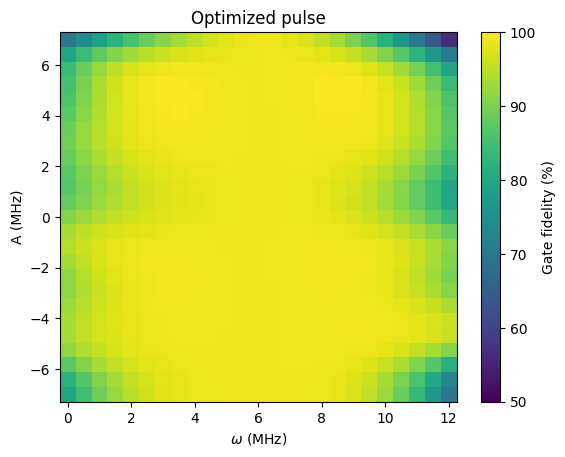

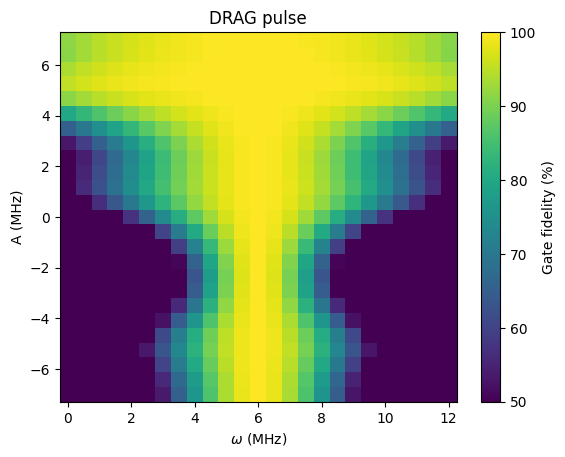

In [9]:
plt.pcolormesh(w2/1e6, A2/1e6, F.T*100, shading='auto', vmin=50, vmax=100)
plt.colorbar(label='Gate fidelity (%)')
plt.xlabel(r'$\omega$ (MHz)')
plt.ylabel('A (MHz)')
plt.title("Optimized pulse")
plt.show()

plt.pcolormesh(w2/1e6, A2/1e6, F0.T*100, shading='auto', vmin=50, vmax=100)
plt.colorbar(label='Gate fidelity (%)')
plt.xlabel(r'$\omega$ (MHz)')
plt.ylabel('A (MHz)')
plt.title("DRAG pulse")
plt.show()